Note on fine-tuning:
In deep learning, fine-tuning usually refers to starting from a pretrained model (like one trained on ImageNet) and adapting it to a new task by continuing training, often with lower learning rates or by freezing some layers. In this exercise, we are explicitly told not to use fine-tuning or pretrained models. However, adjusting hyperparameters like learning rate, batch size, dropout, and using data augmentation is still part of training from scratch — and is allowed. I have built the VGG11-based model manually and trained it from scratch without loading any pretrained weights.

training_images shape: (1500, 3, 96, 96)
training_labels shape: (1500,)
val_images shape: (2400, 3, 96, 96)
val_labels shape: (2400,)
                                              images  labels
0  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       2
1  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       1
2  [[[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0...       0
3  [[[218, 216, 216, 216, 218, 218, 216, 217, 220...       0
4  [[[181, 178, 177, 181, 184, 184, 185, 187, 190...       1


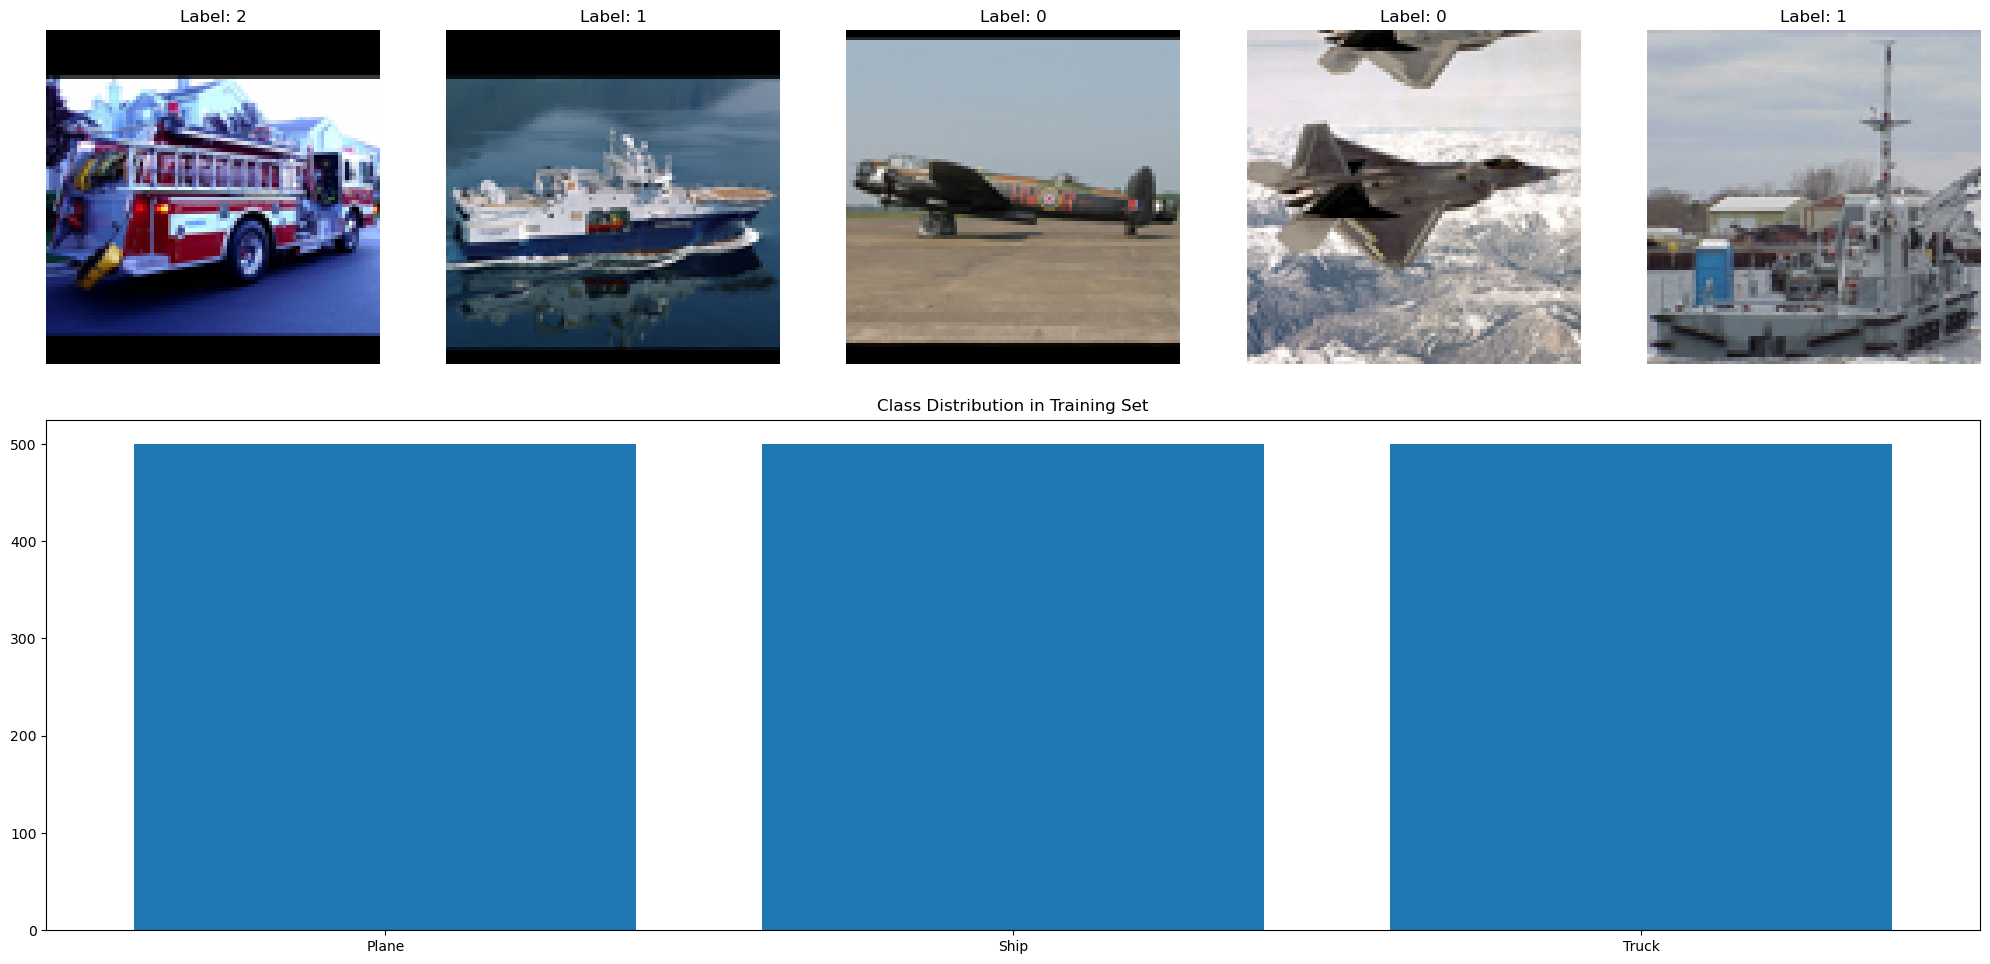

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os

# Add the src folder to the Python path
sys.path.append(os.path.join(os.getcwd(), 'src/'))

training_data = np.load ('data/problem2/training_data.npz')
training_images = training_data ['a' ]
training_labels = training_data ['b']

print('training_images shape:', training_images.shape)
print('training_labels shape:', training_labels.shape)

val_data = np.load('data/problem2/evaluation_data.npz')
val_images = val_data['a']
val_labels = val_data['b']
print('val_images shape:', val_images.shape)
print('val_labels shape:', val_labels.shape)

# converting to dataframe
df = pd.DataFrame({
    'images': list(training_images), # Convert numpy array to list for DataFrame
    'labels': training_labels # Keep labels as is
})

# Display the first few rows of the DataFrame
print(df.head())

import matplotlib.gridspec as gridspec
from collections import Counter

counter = Counter(training_labels)

fig = plt.figure(figsize=(20, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[1, 1.2])

# Top row: display 5 sample images in a row
gs_top = gridspec.GridSpecFromSubplotSpec(1, 5, subplot_spec=gs[0])
for i in range(5):
    ax = fig.add_subplot(gs_top[i])
    img = training_images[i].transpose(1, 2, 0)  # (C, H, W) -> (H, W, C)
    ax.imshow(img)
    ax.set_title(f"Label: {training_labels[i]}")
    ax.axis('off')

# Bottom row: bar chart for the class distribution
ax_bar = fig.add_subplot(gs[1])
ax_bar.bar(list(counter.keys()), list(counter.values()))
ax_bar.set_title("Class Distribution in Training Set")
ax_bar.set_xticks([0, 1, 2])
ax_bar.set_xticklabels(['Plane', 'Ship', 'Truck'])

plt.tight_layout()
plt.show()


I kept the 2a config minimal to isolate the effect of BatchNorm. For 2c, I explored how Dropout benefits from additional regularization and LR scheduling.

Computed mean: [0.44721743 0.46530056 0.48270383]
Computed std: [0.2752397  0.27612755 0.29671028]


=== Training: 2a_SGD_no_dropout_no_sched (Batch size: 32) ===


c:\Users\tihas\Miniconda3\envs\new_py\lib\site-packages\torchvision\transforms\v2\_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
Training 2a_SGD_no_dropout_no_sched_bs32_20250421_224448:  39%|███▉      | 4758/12200 [03:43<05:50, 21.26batch/s, epoch=39/100, phase=val, loss=0.6062, acc=0.8750]  



Early stopping triggered at epoch 39.
Best validation accuracy was 0.8967 at epoch 24.

Best Val Accuracy: 0.8967
Total training time: 223.79s


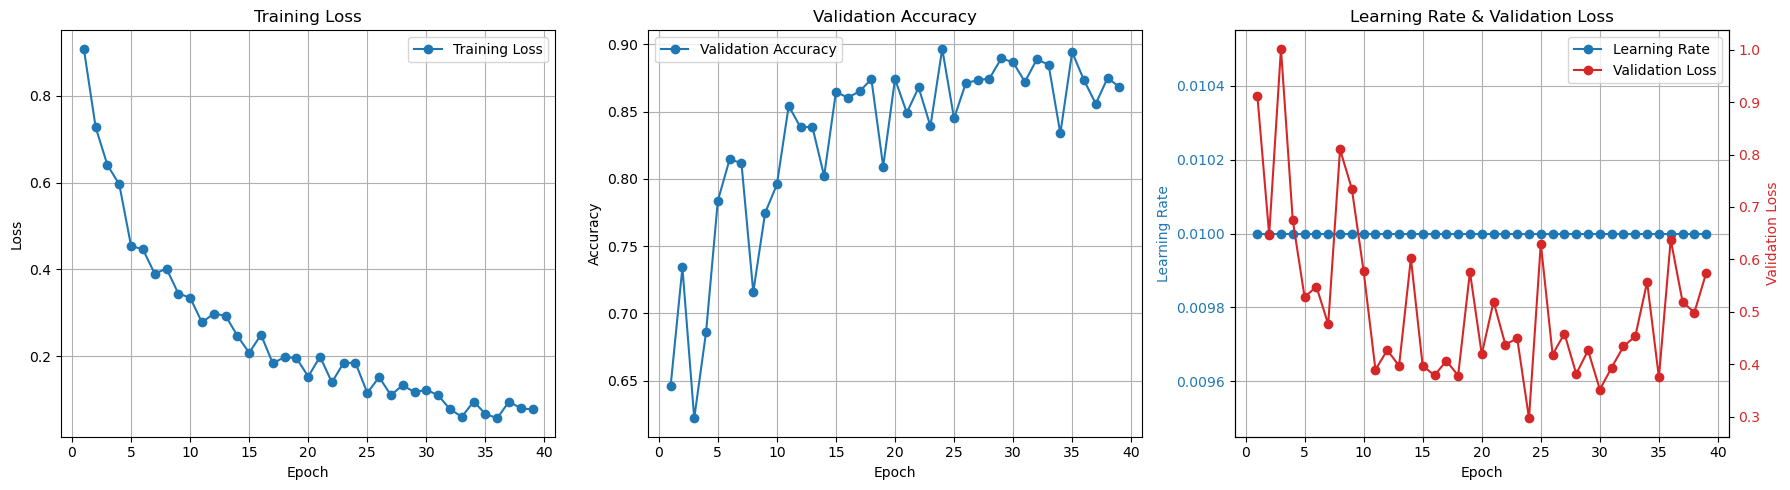

              precision    recall  f1-score   support

       Plane       0.97      0.79      0.87       800
        Ship       0.85      0.90      0.88       800
       Truck       0.81      0.91      0.86       800

    accuracy                           0.87      2400
   macro avg       0.88      0.87      0.87      2400
weighted avg       0.88      0.87      0.87      2400

+------------------------------------------------------+
| Validation Loss: 0.5737, Validation Accuracy: 0.8683 |
+------------------------------------------------------+


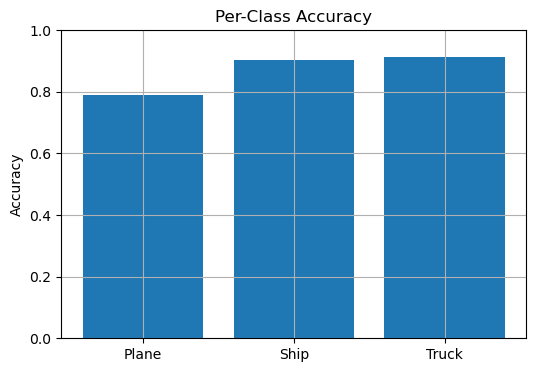



=== Training: 2a_Adam_no_dropout_no_sched (Batch size: 32) ===


Training 2a_Adam_no_dropout_no_sched_bs32_20250421_224836:  52%|█████▏    | 6344/12200 [05:15<04:51, 20.09batch/s, epoch=52/100, phase=val, loss=0.3363, acc=0.9375]  



Early stopping triggered at epoch 52.
Best validation accuracy was 0.9008 at epoch 37.

Best Val Accuracy: 0.9008
Total training time: 315.78s


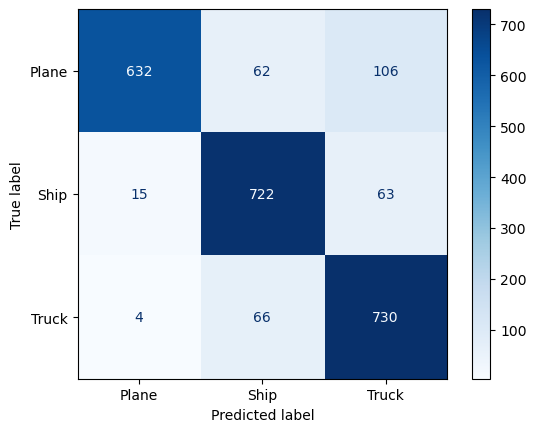

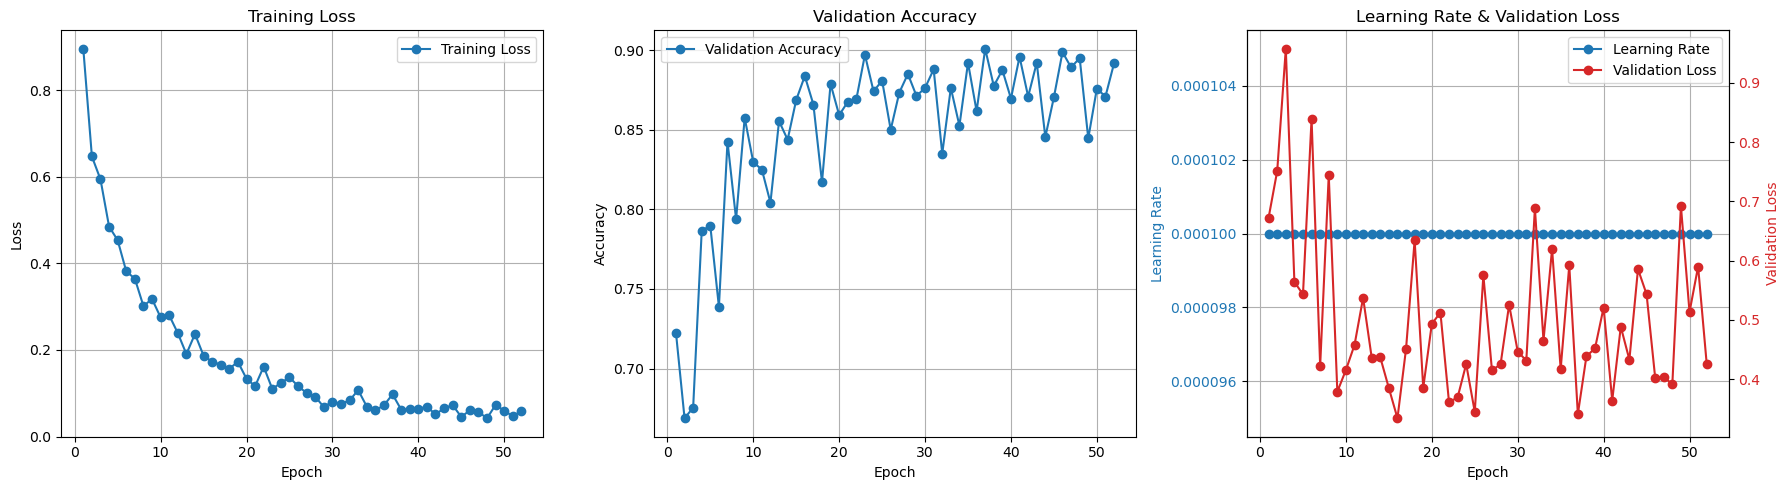

              precision    recall  f1-score   support

       Plane       0.97      0.84      0.90       800
        Ship       0.85      0.92      0.89       800
       Truck       0.87      0.91      0.89       800

    accuracy                           0.89      2400
   macro avg       0.90      0.89      0.89      2400
weighted avg       0.90      0.89      0.89      2400

+------------------------------------------------------+
| Validation Loss: 0.4261, Validation Accuracy: 0.8917 |
+------------------------------------------------------+


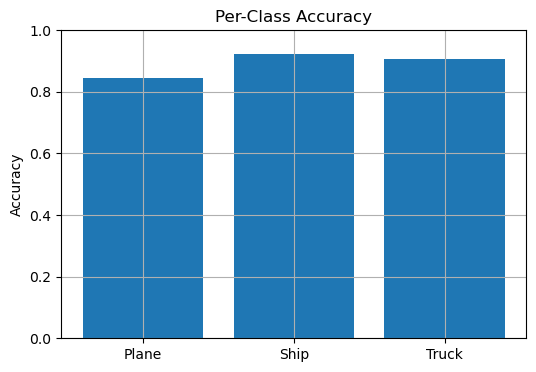



=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250421_225356:  35%|███▌      | 4299/12200 [03:24<11:32, 11.40batch/s, epoch=36/100, phase=train, loss=0.3463, acc=0.8438]

KeyboardInterrupt: 

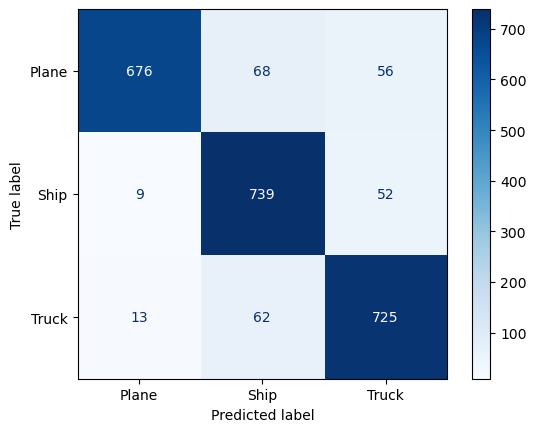

In [2]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics, compute_npz_mean_std
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torchvision.transforms import v2 as transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# mean and std for normalization
train_npz_path = "data/problem2/training_data.npz"
dataset_mean, dataset_std = compute_npz_mean_std(train_npz_path)


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())
])

# Define validation transforms (no augmentation)
val_transform = transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())


# Prepare datasets once
train_dataset = ImageDataset(training_images, training_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2a_SGD_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "sgd",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2a_Adam_no_dropout_no_sched",
        "dropout": False,
        "optimizer": "adam",
        "weight_decay": 0,
        "use_scheduler": False,
        "batch_size": 32
    },
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 0,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 1e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    # scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) if cfg["use_scheduler"] else None
    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    





=== Training: 2c_Adam_dropout_sched (Batch size: 32) ===


Training 2c_Adam_dropout_sched_bs32_20250420_194524:  80%|████████  | 9760/12200 [09:26<02:21, 17.24batch/s, epoch=80/100, phase=val, loss=0.2571, acc=0.9688]  



Early stopping triggered at epoch 80.
Best validation accuracy was 0.9042 at epoch 65.

Best Val Accuracy: 0.9042
Total training time: 566.28s


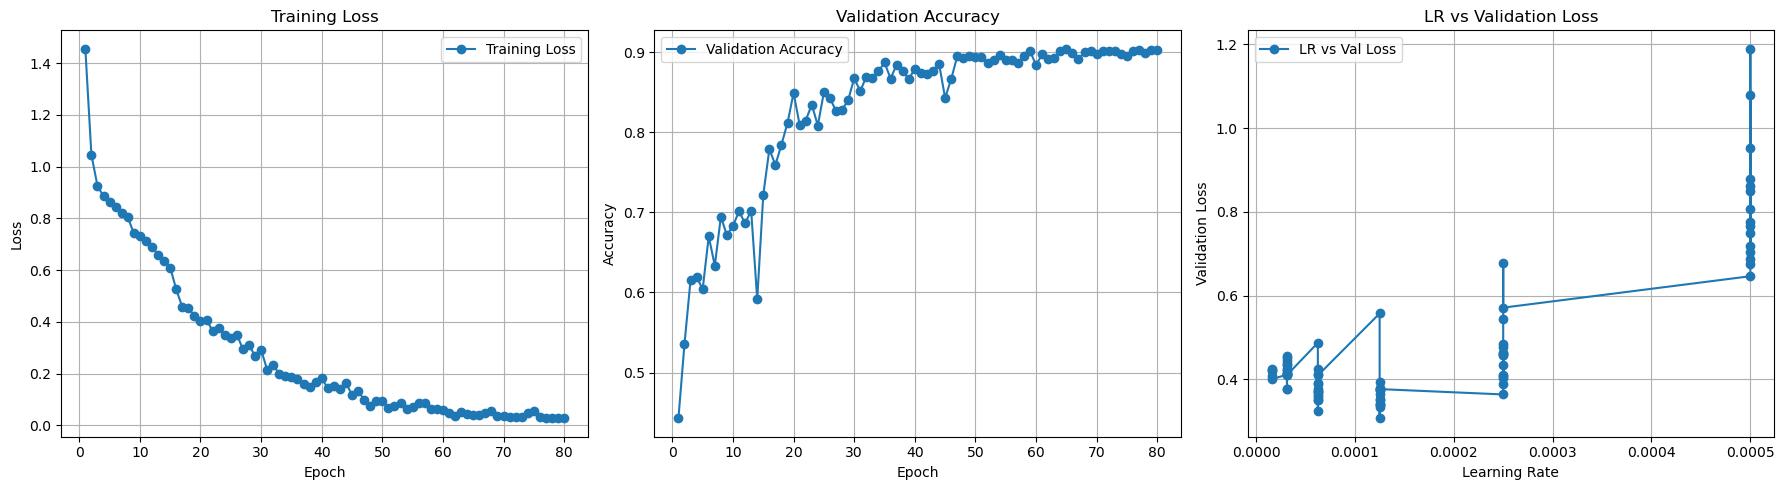

              precision    recall  f1-score   support

       Plane       0.90      0.92      0.91       800
        Ship       0.90      0.89      0.89       800
       Truck       0.91      0.89      0.90       800

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400

+------------------------------------------------------+
| Validation Loss: 0.4216, Validation Accuracy: 0.9021 |
+------------------------------------------------------+


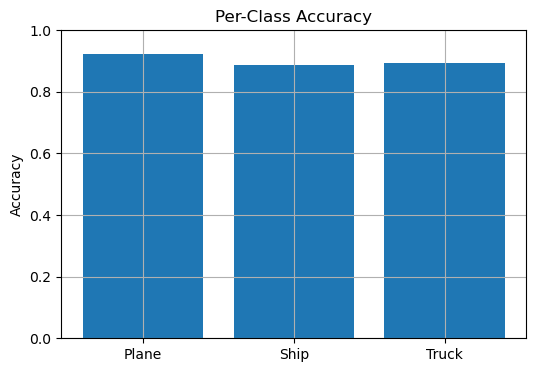



=== Training: 2c_SGD_dropout_sched (Batch size: 32) ===


Training 2c_SGD_dropout_sched_bs32_20250420_195456:  64%|██████▍   | 7808/12200 [07:11<04:02, 18.08batch/s, epoch=64/100, phase=val, loss=0.4752, acc=0.9375]  



Early stopping triggered at epoch 64.
Best validation accuracy was 0.9117 at epoch 49.

Best Val Accuracy: 0.9117
Total training time: 431.93s


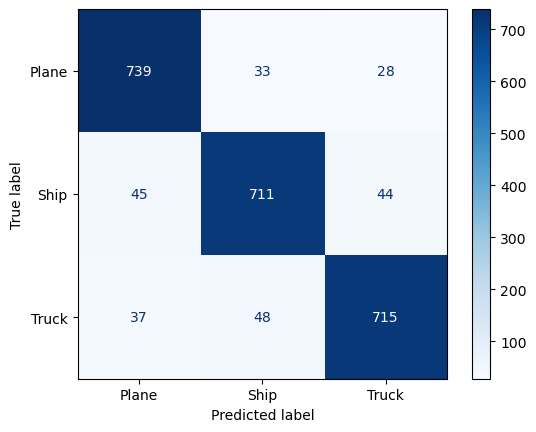

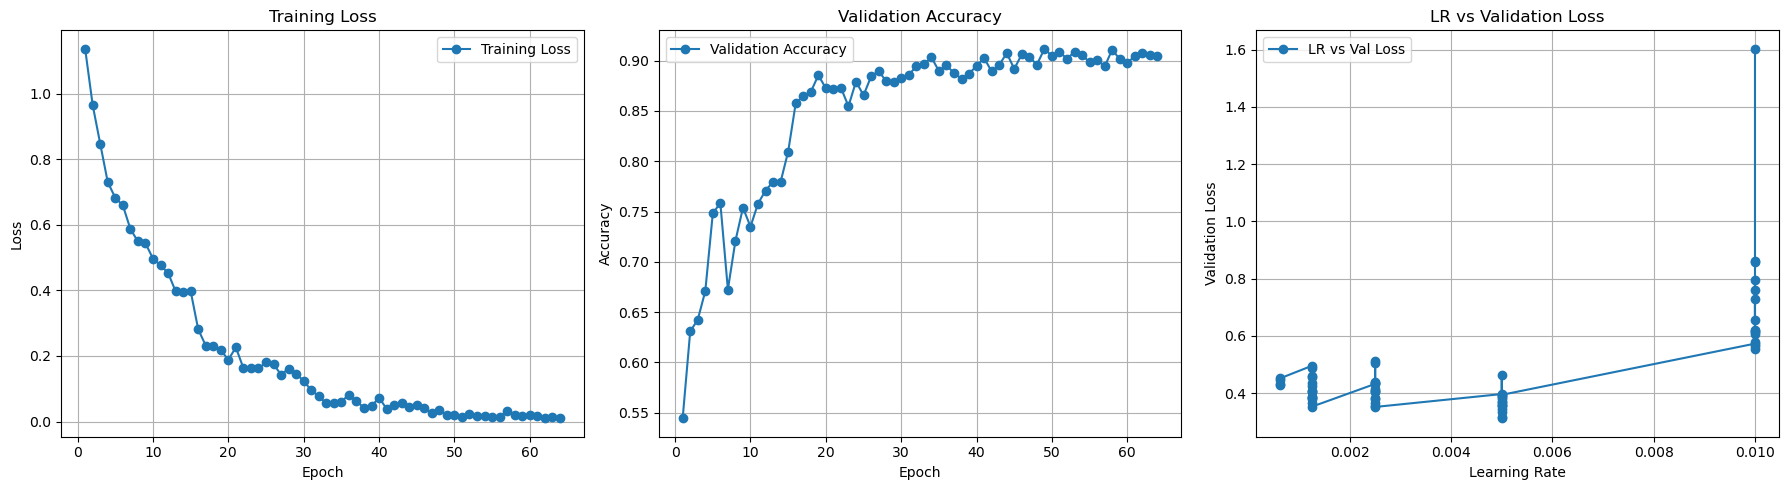

              precision    recall  f1-score   support

       Plane       0.93      0.91      0.92       800
        Ship       0.89      0.90      0.90       800
       Truck       0.89      0.90      0.90       800

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400

+------------------------------------------------------+
| Validation Loss: 0.4281, Validation Accuracy: 0.9046 |
+------------------------------------------------------+


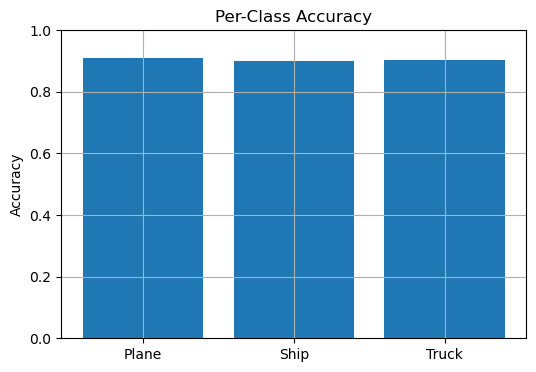



=== Training: 2c_Adam_dropout_sched (Batch size: 64) ===


Training 2c_Adam_dropout_sched_bs64_20250420_200214:  46%|████▌     | 2852/6200 [04:53<05:45,  9.70batch/s, epoch=46/100, phase=val, loss=0.3926, acc=0.9062]  



Early stopping triggered at epoch 46.
Best validation accuracy was 0.8833 at epoch 31.

Best Val Accuracy: 0.8833
Total training time: 293.93s


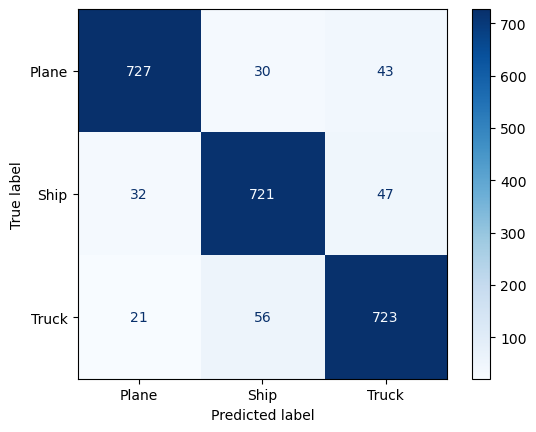

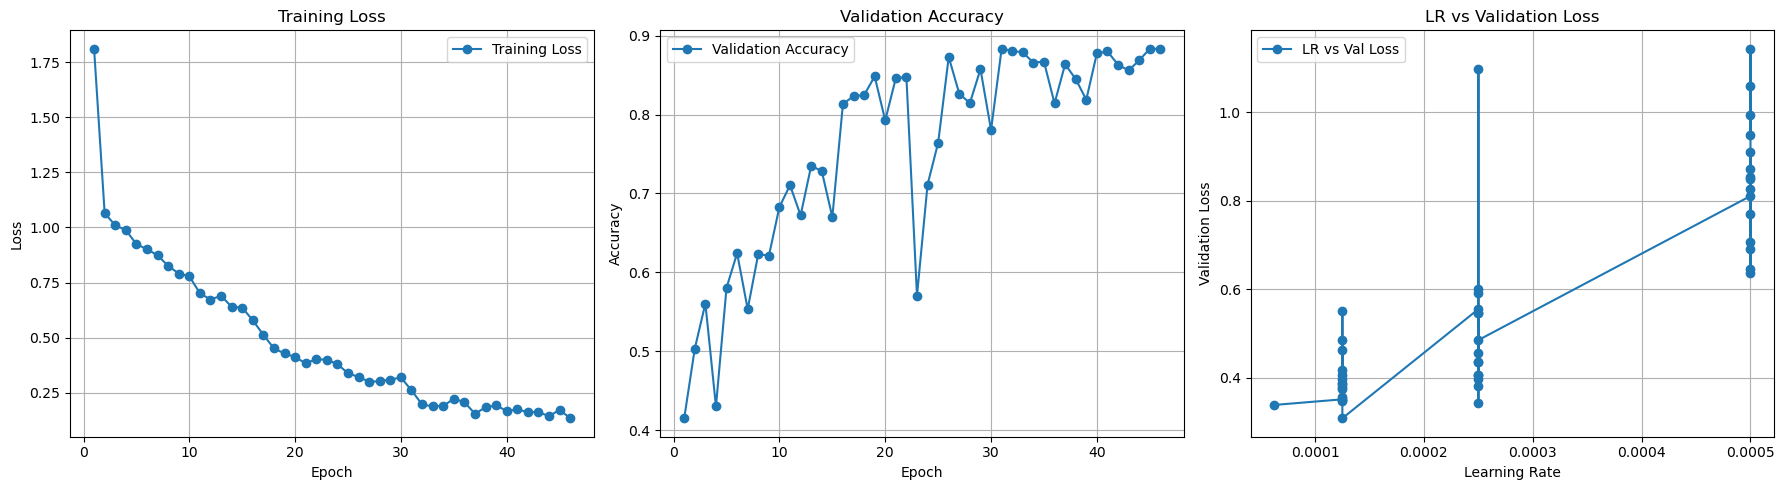

              precision    recall  f1-score   support

       Plane       0.88      0.91      0.89       800
        Ship       0.86      0.88      0.87       800
       Truck       0.91      0.86      0.89       800

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400

+------------------------------------------------------+
| Validation Loss: 0.3390, Validation Accuracy: 0.8833 |
+------------------------------------------------------+


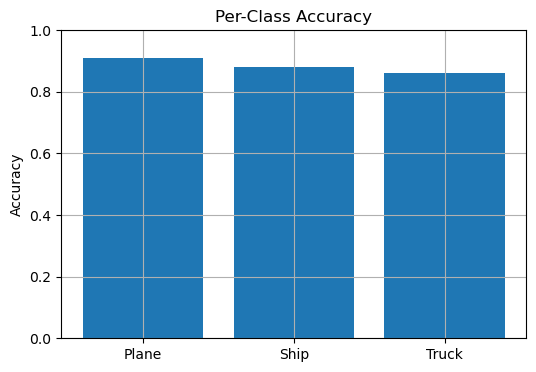

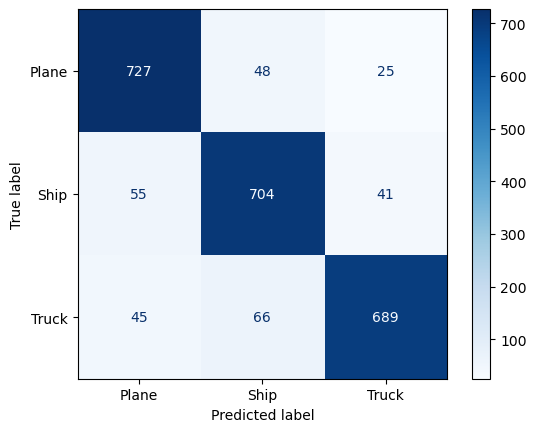

In [ ]:
from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torchvision.transforms import v2 as transforms

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=dataset_mean.tolist(), std=dataset_std.tolist())
])


# Prepare datasets once
train_dataset = ImageDataset(training_images, training_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)

# can uncomment the following lines to create datasets again without augmentation
# train_dataset = ImageDataset(train_images, train_labels)
# val_dataset = ImageDataset(val_images, val_labels)

# Define experiment configurations
configs = [
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_SGD_dropout_sched",
        "dropout": True,
        "optimizer": "sgd",
        "weight_decay": 0,
        "use_scheduler": True,
        "batch_size": 32
    },
    {
        "name": "2c_Adam_dropout_sched",
        "dropout": True,
        "optimizer": "adam",
        "weight_decay": 1e-4,
        "use_scheduler": True,
        "batch_size": 64
    }
]



# Run each experiment
for cfg in configs:
    print(f"\n\n=== Training: {cfg['name']} (Batch size: {cfg['batch_size']}) ===")

    # Create dataloaders with specified batch size
    dataloaders = {
        'train': DataLoader(
            train_dataset,
            batch_size=cfg['batch_size'],
            shuffle=True,
            pin_memory=True
        ),
        'val': DataLoader(
            val_dataset,
            batch_size=cfg['batch_size'],
            shuffle=False,
            pin_memory=True
        )
    }

    # Create model and loss function
    model = VGG11BN(num_classes=3, dropout=cfg["dropout"]).to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Setup optimizer based on configuration
    optimizer_name = cfg.get("optimizer", "adam").lower()
    lr = cfg.get("lr", 1e-2 if optimizer_name == 'sgd' else 5e-4) # default lr for SGD and Adam; override in config if needed
    if optimizer_name == "sgd":
        optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"],momentum=0.9)
    else:
        optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=cfg["weight_decay"])

    # Setup scheduler (if any)
    # scheduler = StepLR(optimizer, step_size=15, gamma=0.5) if cfg["use_scheduler"] else None
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=2) if cfg["use_scheduler"] else None

    # Train the model
    trained_model = train_model(
        model=model,
        dataloaders=dataloaders,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        device=device,
        num_epochs=100,
        model_name=f"{cfg['name']}_bs{cfg['batch_size']}",
        patience=15
    )

    # Evaluate the model
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=trained_model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )

    print_framed_metrics(val_loss, val_acc)

    plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'],
                        save_path=f"plots/{cfg['name']}_per_class_acc.png")

    # Generate plots
    plot_confusion_matrix(
        trained_model,
        dataloaders['val'],
        device,
        class_names=['Plane', 'Ship', 'Truck'],
        save_path=f"plots/{cfg['name']}_bs{cfg['batch_size']}_confusion_matrix.png"
    )
    



C:\Users\tihas\AppData\Local\Temp\ipykernel_14428\249698010.py:70: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path))


              precision    recall  f1-score   support

       Plane       0.94      0.87      0.90       100
        Ship       0.90      0.90      0.90       100
       Truck       0.88      0.94      0.91       100

    accuracy                           0.90       300
   macro avg       0.90      0.90      0.90       300
weighted avg       0.90      0.90      0.90       300


🧪 Best Model Evaluation:
Validation Loss: 0.4400, Accuracy: 0.9033


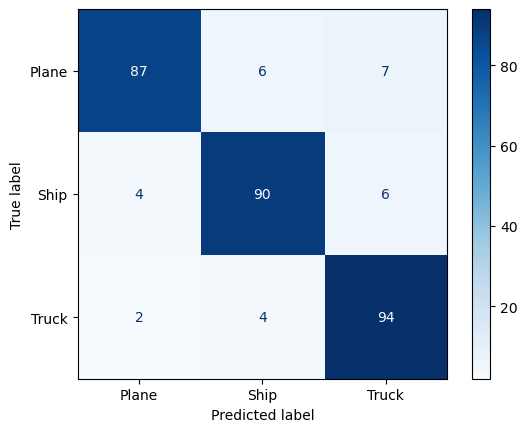

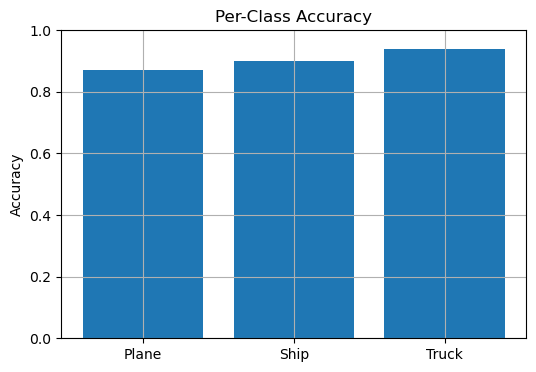

In [ ]:
# === Load and evaluate best saved model ===

import torch
from src.vgg11bn import VGG11BN
from src.evaluation import classification_summary, plot_confusion_matrix, plot_multiclass_roc
from torch import nn


from torch.utils.data import DataLoader
from src.utils import ImageDataset, set_seed, print_framed_metrics
from src.vgg11bn import VGG11BN
from src.train import train_model
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import transforms

# Defining data augmentation transforms for training
train_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.RandomResizedCrop(96, scale=(0.8, 1.0)),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Define validation transforms (no augmentation)
val_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])


# Prepare datasets once
train_dataset = ImageDataset(training_images, training_labels, transform=train_transform)
val_dataset = ImageDataset(val_images, val_labels, transform=val_transform)
# Create dataloaders with specified batch size
dataloaders = {
    'train': DataLoader(
        train_dataset,
        batch_size=32,
        shuffle=True,
        pin_memory=True
    ),
    'val': DataLoader(
        val_dataset,
        batch_size=32,
        shuffle=False,
        pin_memory=True
    )
}


# Set seed and device
set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# === Replace this with the actual path to your best model ===
# best_model_path = "models/2c_Adam_dropout_sched_bs32_20250418_15043_best.pth"
best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_Adam_dropout_sched_bs32_20250418_150043_best.pth"
# best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_SGD_dropout_sched_bs32_20250418_145552_best.pth"
# === Rebuild the same model architecture as used during training ===
model = VGG11BN(num_classes=3, dropout=True)  # <-- Set dropout=True/False as used in training
model.load_state_dict(torch.load(best_model_path))
model.to(device)
model.eval()

# === Loss function (same as training) ===
criterion = nn.CrossEntropyLoss()

# === Evaluate and print classification summary ===
val_loss, val_acc, y_true, y_pred = classification_summary(
    model=model,
    dataloader=dataloaders["val"],
    criterion=criterion,
    device=device,
    class_names=['Plane', 'Ship', 'Truck']
)

print(f"\n🧪 Best Model Evaluation:\nValidation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

# === Optional plots ===
plot_confusion_matrix(model, dataloaders['val'], device, class_names=['Plane', 'Ship', 'Truck'])
plot_per_class_accuracy(y_true, y_pred, class_names=['Plane', 'Ship', 'Truck'])


In [10]:
import os
from glob import glob
import torch
import torch.nn as nn
from src.vgg11bn import VGG11BN
from src.utils import set_seed
from src.evaluation import classification_summary, plot_confusion_matrix, plot_per_class_accuracy

set_seed(42)
model_dir = "models"
model_paths = glob(os.path.join(model_dir, "*_best.pth"))
print(f"\n Found {len(model_paths)} best model(s) to evaluate:\n")

# Track the best model
best_model = None
best_model_path = ""
best_accuracy = 0.0
best_loss = float("inf")
results = []

for path in sorted(model_paths):
    use_dropout = "dropout" in path.lower()
    model_name = os.path.basename(path)


    model = VGG11BN(num_classes=3, dropout=use_dropout)
    model.load_state_dict(torch.load(path, map_location=device))
    model.to(device)
    model.eval()

    criterion = nn.CrossEntropyLoss()
    val_loss, val_acc, y_true, y_pred = classification_summary(
        model=model,
        dataloader=dataloaders["val"],
        criterion=criterion,
        device=device,
        class_names=['Plane', 'Ship', 'Truck']
    )


    results.append((model_name, val_loss, val_acc))

    # Check if this is the best model
    if (val_acc > best_accuracy) or (val_acc == best_accuracy and val_loss < best_loss):
        best_accuracy = val_acc
        best_loss = val_loss
        best_model = model
        best_model_path = path

# Sort results by accuracy desc, loss asc
results_sorted = sorted(results, key=lambda x: (-x[2], x[1]))

# Summary
# print(f"\n Best Model: {os.path.basename(best_model_path)}")
# print(f"   Accuracy: {best_accuracy:.4f} | Loss: {best_loss:.4f}")

# print("\n Model Performance Summary (sorted):")
# print(f"{'Model Name':<50} | {'Accuracy':>8} | {'Loss':>8}")
# print("-" * 75)
for name, loss, acc in results_sorted:
    print(f"{name:<50} | {acc:8.4f} | {loss:8.4f}")



 Found 18 best model(s) to evaluate:



C:\Users\tihas\AppData\Local\Temp\ipykernel_4532\890555310.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


              precision    recall  f1-score   support

       Plane       0.83      0.93      0.87       800
        Ship       0.88      0.81      0.84       800
       Truck       0.89      0.86      0.87       800

    accuracy                           0.86      2400
   macro avg       0.87      0.86      0.86      2400
weighted avg       0.87      0.86      0.86      2400



C:\Users\tihas\AppData\Local\Temp\ipykernel_4532\890555310.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


              precision    recall  f1-score   support

       Plane       0.92      0.88      0.90       800
        Ship       0.85      0.89      0.87       800
       Truck       0.86      0.87      0.87       800

    accuracy                           0.88      2400
   macro avg       0.88      0.88      0.88      2400
weighted avg       0.88      0.88      0.88      2400



...

              precision    recall  f1-score   support

       Plane       0.98      0.70      0.82       800
        Ship       0.80      0.90      0.85       800
       Truck       0.77      0.90      0.83       800

    accuracy                           0.83      2400
   macro avg       0.85      0.83      0.83      2400
weighted avg       0.85      0.83      0.83      2400



C:\Users\tihas\AppData\Local\Temp\ipykernel_4532\890555310.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


              precision    recall  f1-score   support

       Plane       0.95      0.88      0.91       800
        Ship       0.89      0.90      0.90       800
       Truck       0.87      0.93      0.89       800

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400



C:\Users\tihas\AppData\Local\Temp\ipykernel_4532\890555310.py:27: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(path, map_location=device))


              precision    recall  f1-score   support

       Plane       0.93      0.91      0.92       800
        Ship       0.89      0.90      0.90       800
       Truck       0.89      0.90      0.90       800

    accuracy                           0.90      2400
   macro avg       0.90      0.90      0.90      2400
weighted avg       0.90      0.90      0.90      2400

2c_SGD_dropout_sched_bs32_20250420_195456_best.pth |   0.9046 |   0.4281
2c_SGD_dropout_sched_bs32_20250418_180811_best.pth |   0.9038 |   0.4062
2c_Adam_dropout_sched_bs32_20250418_150043_best.pth |   0.9033 |   0.4407
2c_Adam_dropout_sched_bs32_20250420_194524_best.pth |   0.9021 |   0.4216
2c_SGD_dropout_sched_bs32_20250420_191631_best.pth |   0.9017 |   0.3925
2c_Adam_dropout_sched_bs32_20250418_181216_best.pth |   0.8996 |   0.4216
2c_Adam_dropout_sched_bs32_20250420_192319_best.pth |   0.8992 |   0.4880
2c_Adam_dropout_sched_bs32_20250418_181841_best.pth |   0.8975 |   0.4645
2c_Adam_dropout_sched_64_bs64_

During experimentation, I observed minor variations in performance when training the same model setup on different machines (e.g., local vs remote). While seed setting and deterministic flags were applied, hardware differences (e.g., GPU type, cuDNN backend, etc.) likely contributed to nondeterministic behavior. This is a known challenge in deep learning reproducibility and did not affect overall conclusions drawn from the trends observed across experiments.

2d


In [1]:
import torch
import torch.nn.functional as F
import numpy as np
from torch.utils.data import DataLoader, Dataset
from src.utils import ImageDataset, set_seed
from src.evaluation import plot_entropy_hist

# Set seed 
set_seed(42)



# --- Load data with real known/unknown labels ---
eval_data = np.load('data/problem2/new_evaluation_data_with_labels.npz')
eval_images = eval_data['a']          # shape: (N, 96, 96, 3)
eval_labels = eval_data['b']          # shape: (N,)

# -- Load unlabeled data --
unlabeled_data = np.load('data/problem2/new_evaluation_data_without_labels.npz')
unlabeled_images = unlabeled_data['a']  # No labels here, just the images

# Split data into known and unknown using labels
known_images = eval_images[eval_labels != 3]
unknown_images = eval_images[eval_labels == 3]


# --- DataLoaders ---
known_loader = DataLoader(ImageDataset(known_images), batch_size=32, shuffle=False)
unknown_loader = DataLoader(ImageDataset(unknown_images), batch_size=32, shuffle=False)



To properly perform MC Dropout inference, we set the model to .eval() mode to freeze BatchNorm layers and maintain stable running statistics, while manually reactivating Dropout layers using a custom enable_dropout() function. This allows us to simulate model uncertainty without introducing noise from fluctuating batch statistics, which could otherwise corrupt the entropy estimation.


To perform Monte Carlo Dropout inference correctly, the model is first set to `.eval()` mode to freeze all layers, including Batch Normalization, which ensures that it uses stable running statistics instead of noisy batch statistics. However, since we need Dropout to remain active for uncertainty estimation, we selectively re-enable only the Dropout layers using a custom `enable_dropout()` utility. This approach allows us to simulate stochastic forward passes for uncertainty modeling while keeping the evaluation behavior of other layers intact.


C:\Users\tihas\AppData\Local\Temp\ipykernel_13464\2588827826.py:12: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_locat

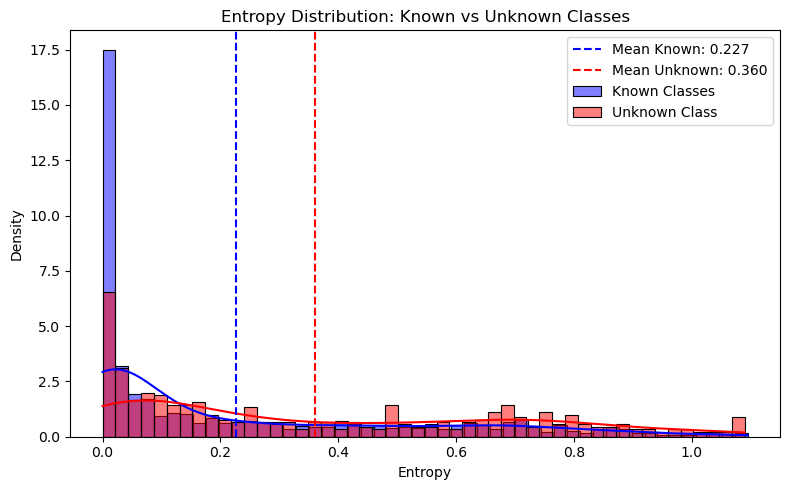

Known Entropy - Mean: 0.2268, Std: 0.2878
Unknown Entropy - Mean: 0.3603, Std: 0.3237


In [30]:
from src.vgg11bn import VGG11BN
from src.utils import enable_dropout, mc_dropout_inference
from src.evaluation import plot_entropy_hist
import torch.nn.functional as F

# Set seed and device
set_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Load model
best_model_path = "C:/Users/tihas/OneDrive - UiT Office 365/A_UIT/FYS-3033/HOME_EXAM/FYS3033DL/models/2c_SGD_dropout_sched_bs32_20250420_195456_best.pth"
model = VGG11BN(num_classes=3, dropout=True)
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

model.eval()
enable_dropout(model)  # Activate dropout only

# Entropy lists
entropies_known = []
entropies_unknown = []

# Loop over known samples
for sample in known_loader:
    imgs = sample[0] if isinstance(sample, tuple) else sample # Unpack if it's a tuple (e.g., (data, labels)), otherwise use sample directly
    for img in imgs:
        mean_probs, entropy = mc_dropout_inference(model, img, T=10, device=device)
        entropies_known.append(entropy)

# Loop over unknown samples
for sample in unknown_loader:
    imgs = sample[0] if isinstance(sample, tuple) else sample
    for img in imgs:
        mean_probs, entropy = mc_dropout_inference(model, img, T=10)
        entropies_unknown.append(entropy)

# Plot histograms
plot_entropy_hist(entropies_known, entropies_unknown)

# Print stats
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)
std_known = np.std(entropies_known)
std_unknown = np.std(entropies_unknown)
print(f"Known Entropy - Mean: {mean_known:.4f}, Std: {std_known:.4f}")
print(f"Unknown Entropy - Mean: {mean_unknown:.4f}, Std: {std_unknown:.4f}")


min/max entropy: 1.0069150135905147e-07 1.090421438217163


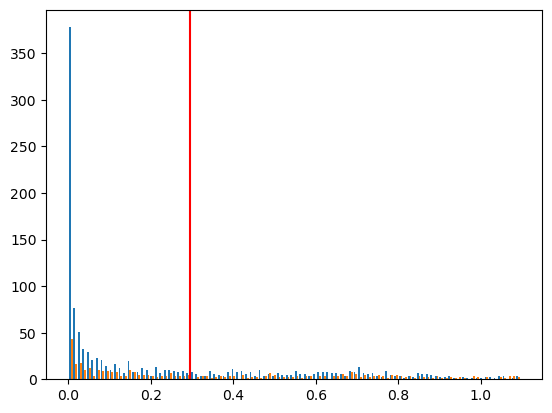

In [32]:
# after you collect entropies:
print("min/max entropy:", np.min(entropies_known), np.max(entropies_unknown))

import matplotlib.pyplot as plt
plt.hist((entropies_known,entropies_unknown), bins=100)
plt.axvline(midpoint_threshold, color='red'); plt.show()


To measure how uncertain the model is about its predictions, I used entropy of the softmax output. Entropy captures how "spread out" the predicted probabilities are. If the model is very confident about its prediction, the softmax output will be sharply peaked (e.g., close to [0, 0, 1]), which results in low entropy. But if the model is unsure, the probabilities will be more evenly distributed (e.g., [0.3, 0.4, 0.3]), leading to higher entropy. That’s why entropy is a useful way to quantify uncertainty.

To test this, I ran MC Dropout on each image in the labeled evaluation dataset. This gave me 10 softmax predictions per image, which I averaged and then computed the entropy from. I split the data into two groups based on the labels: the known classes (planes, ships, and trucks), and the unknown class (birds).

Then I plotted a histogram comparing the entropy of the known vs unknown class. I also marked the mean entropy of each group. What I saw matched what I expected: the entropy was generally higher for the unknown class. The mean entropy for the known classes was around 0.266, while for the unknown class it was about 0.345. This makes sense since the model was never trained on birds, so it is more uncertain about them.

Even though the two distributions overlap, the shift in mean suggests that entropy can help separate known and unknown samples. It’s not perfect, but it shows that using entropy is a reasonable approach for identifying images from classes the model hasn't seen before.


### (2e)


Best Threshold: 0.0653
AUC: 0.6542


Training 2a_SGD_no_dropout_no_sched_bs32_20250420_212824:   0%|          | 20/12200 [28:55<293:34:51, 86.77s/batch, epoch=1/100, phase=train, loss=0.9451, acc=0.5000]


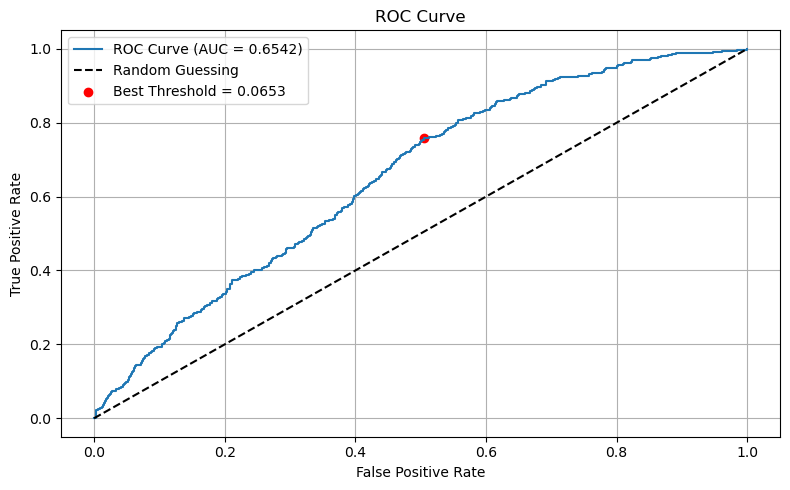

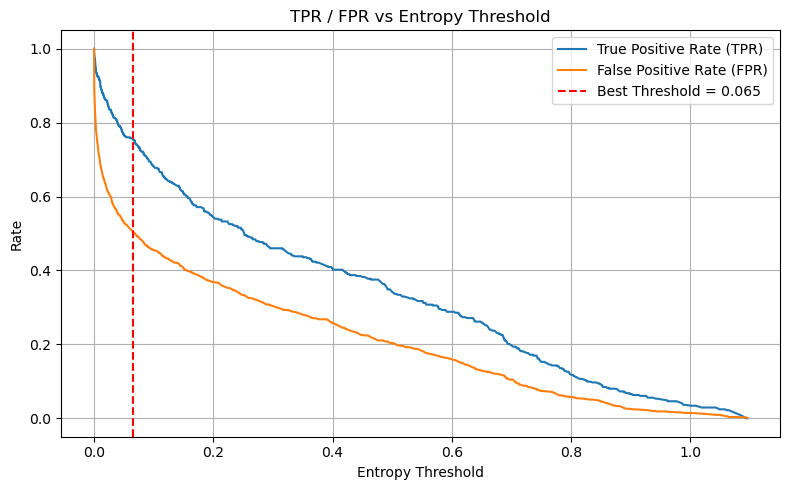

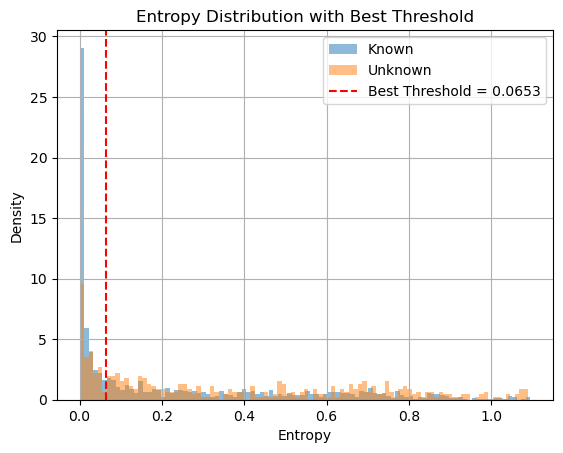

In [41]:
# finding the best threshold

from sklearn.metrics import roc_curve,roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

# combining labels: 0 for known, 1 for unknown
labels_combined = np.concatenate([
    np.zeros(len(entropies_known)),  # Known samples
    np.ones(len(entropies_unknown))   # Unknown samples
])

# combining entropies
entropies_combined = np.concatenate([
    entropies_known,
    entropies_unknown
])

# compute ROC
fpr, tpr, thresholds = roc_curve(labels_combined, entropies_combined)

# compute Youden's J statistic

J = tpr - fpr
best_idx = np.argmax(J)  # reverse indexing to handle descending thresholds
best_threshold = thresholds[best_idx]


# compute AUC
auc = roc_auc_score(labels_combined, entropies_combined)

print(f"Best Threshold: {best_threshold:.4f}")
print(f"AUC: {auc:.4f}")

# Plot ROC curve
plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing')
plt.scatter(fpr[best_idx], tpr[best_idx], color='red', label=f"Best Threshold = {best_threshold:.4f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.savefig("plots/roc_curve_entropy.png")
plt.show()

# Plot TPR and FPR vs Entropy Threshold

plt.figure(figsize=(8,5))
plt.plot(thresholds, tpr, label="True Positive Rate (TPR)")
plt.plot(thresholds, fpr, label="False Positive Rate (FPR)")
plt.axvline(best_threshold, color='red', linestyle='--', label=f"Best Threshold = {best_threshold:.3f}")
plt.xlabel("Entropy Threshold")
plt.ylabel("Rate")
plt.title("TPR / FPR vs Entropy Threshold")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

plt.hist(entropies_known, bins=100, alpha=0.5, label='Known', density=True)
plt.hist(entropies_unknown, bins=100, alpha=0.5, label='Unknown', density=True)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Best Threshold = {best_threshold:.4f}')
plt.xlabel('Entropy')
plt.ylabel('Density')
plt.title('Entropy Distribution with Best Threshold')
plt.legend()
plt.grid()
plt.savefig("plots/entropy_distribution_with_threshold.png")
plt.show()


In [38]:
# (2e) step 2 : counting how many birds are detected and how many knowns that are wrongly removed
from src.utils import ImageDataset, set_seed
from torch.utils.data import DataLoader

# preprocessing the eval data
eval_dataset = ImageDataset(eval_images, eval_labels, transform=val_transform)
eval_loader = DataLoader(eval_dataset, batch_size=32, shuffle=False)
# Count variables 
detected_birds = 0
removed_knowns = 0
total_birds = 0
total_knowns = 0
# best_threshold = 0.41  # Set the best threshold from the previous step
# Looping over all the labeled eval images
for imgs, labels in eval_loader:
    for img, label in zip(imgs, labels):
        label = label.item()  # Convert label tensor to int

        mean_probs, entropy = mc_dropout_inference(model, img, T=10, device=device)

        if label == 3:  # Bird
            total_birds += 1
            if entropy >= best_threshold:
                detected_birds += 1
        else:  # Known class
            total_knowns += 1
            if entropy >= best_threshold:
                removed_knowns += 1


# Print results
print(f"Detected Birds: {detected_birds}/{total_birds} ({detected_birds/total_birds*100:.2f}%)")
print(f"Removed Known Samples: {removed_knowns}/{total_knowns} ({removed_knowns/total_knowns*100:.2f}%)")
print(f"Total Birds: {total_birds}")
print(f"Total Known Samples: {total_knowns}")
print(f"Best Threshold: {best_threshold:.4f}")



Detected Birds: 218/413 (52.78%)
Removed Known Samples: 206/1187 (17.35%)
Total Birds: 413
Total Known Samples: 1187
Best Threshold: 0.0653


In [31]:
# 2e – Alternative Threshold: Midpoint between class means
import numpy as np

# Convert lists to numpy arrays
entropies_known = np.array(entropies_known)
entropies_unknown = np.array(entropies_unknown)

# Compute mean entropies
mean_known = np.mean(entropies_known)
mean_unknown = np.mean(entropies_unknown)

# Midpoint threshold
midpoint_threshold = (mean_known + mean_unknown) / 2

# Apply threshold
detected_birds = np.sum(entropies_unknown > midpoint_threshold)
removed_knowns = np.sum(entropies_known > midpoint_threshold)
total_birds = len(entropies_unknown)
total_knowns = len(entropies_known)

# Report results
print(f"Alternative Threshold (Mean of Means): {midpoint_threshold:.4f}")
print(f"Detected Birds: {detected_birds}/{total_birds} ({detected_birds / total_birds * 100:.2f}%)")
print(f"Removed Known Samples: {removed_knowns}/{total_knowns} ({removed_knowns / total_knowns * 100:.2f}%)")


Alternative Threshold (Mean of Means): 0.2936
Detected Birds: 192/413 (46.49%)
Removed Known Samples: 365/1187 (30.75%)


In [39]:
# 2f 
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.utils import ImageDataset, enable_dropout, mc_dropout_inference

# ---- Model prep ----
model.eval()
enable_dropout(model)  # Keep dropout active for MC Dropout

# ---- Threshold selection ----
# Use the best performing threshold from Task 2e (Youden's J)
entropy_threshold = best_threshold

# ---- Dataset and loader for unlabeled data ----
unlabeled_dataset = ImageDataset(unlabeled_images, transform=val_transform)  # No labels
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=1, shuffle=False)

# ---- Run predictions ----
binary_predictions = []

for batch in unlabeled_loader:
    img = batch if not isinstance(batch, tuple) else batch[0]
    img = img.squeeze(0)  # (1, C, H, W) → (C, H, W)

    _, entropy = mc_dropout_inference(model, img, T=10, device=device)
    prediction = 1 if entropy >= entropy_threshold else 0  # 1 = bird
    binary_predictions.append(prediction)

# ---- Save results ----
binary_predictions = np.array(binary_predictions)
np.savez('binary_predictions.npz', predictions=binary_predictions)
print(" Saved binary predictions to 'binary_predictions.npz'")
print(f"Predicted {np.sum(binary_predictions)} unknowns (1) and {len(binary_predictions) - np.sum(binary_predictions)} knowns (0)")
assert binary_predictions.shape == (1600,), "Shape should be (1600,)"


 Saved binary predictions to 'binary_predictions.npz'
Predicted 439 unknowns (1) and 1161 knowns (0)


In [40]:
# 2f 
import numpy as np
import torch
from torch.utils.data import DataLoader
from src.utils import ImageDataset, enable_dropout, mc_dropout_inference

# ---- Model prep ----
model.eval()
enable_dropout(model)  # Keep dropout active for MC Dropout

# ---- Threshold selection ----
entropy_threshold = midpoint_threshold  


# ---- Val transform ----
val_transform = transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)

# ---- Dataset and loader for unlabeled data ----
unlabeled_dataset = ImageDataset(unlabeled_images, transform=val_transform)  # No labels
unlabeled_loader = DataLoader(unlabeled_dataset, batch_size=1, shuffle=False)



# ---- Run predictions ----
binary_predictions = []

for batch in unlabeled_loader:
    img = batch if not isinstance(batch, tuple) else batch[0]
    img = img.squeeze(0)  # (1, C, H, W) → (C, H, W)

    _, entropy = mc_dropout_inference(model, img, T=10, device=device)
    prediction = 1 if entropy >= entropy_threshold else 0  # 1 = bird
    binary_predictions.append(prediction)

# ---- Save results ----
binary_predictions = np.array(binary_predictions)
np.savez('binary_predictions_midpoint.npz', predictions=binary_predictions)
print("Saved binary predictions to 'binary_predictions_midpoint.npz'")
print(f"Predicted {np.sum(binary_predictions)} unknowns (1) and {len(binary_predictions) - np.sum(binary_predictions)} knowns (0)")
assert binary_predictions.shape == (1600,), "Shape should be (1600,)"


Saved binary predictions to 'binary_predictions_midpoint.npz'
Predicted 256 unknowns (1) and 1344 knowns (0)
